In [1]:
from mdcrow import MDCrow
from langchain.callbacks import get_openai_callback
from datetime import datetime
import os 
import traceback

In [2]:
import sys
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '../'))
sys.path.append(parent_dir)
from robustness_prompts import get_prompt # noqa: E402

prompt_9_natural = get_prompt("natural", 9)

prompt_9_natural

'Simulate 1LYZ for 1ps at 300 K and for 1ps at 400K. Report the secondary structure assignments of the downloaded PDB structure and any known binding or active sites. Compute SASA and radius of gyration of the 300K simulation. Compute RMSD of both simulations.'

In [3]:
llm_model = "gpt-4-1106-preview"
tools = "all"

In [4]:
agent = MDCrow(
    agent_type="Structured", 
    model=llm_model, 
    top_k_tools=tools, 
    use_memory=False,
    streaming=False,
    verbose=True,
)
with get_openai_callback() as cb:
    chat_start = datetime.now()
    try:
        response = agent.run(prompt_9_natural, callbacks=[cb])
        print(response)
    except Exception as e:
        exc_type, exc_value, exc_traceback = sys.exc_info()
        print(f'{type(e).__name__}:{e}')
        print("".join(traceback.format_exception(exc_type, exc_value, exc_traceback)))
    chat_end = datetime.now()
    total_runtime = (chat_end - chat_start).total_seconds()
    print(cb)
    print(f"Total runtime: {total_runtime:.2f}s")



> Entering new AgentExecutor chain...


Thought: The question requires multiple steps to address. First, I need to simulate the protein 1LYZ at two different temperatures (300K and 400K) for 1 picosecond each. Then, I need to report the secondary structure assignments of the downloaded PDB structure and any known binding or active sites. Additionally, I need to compute the Solvent Accessible Surface Area (SASA) and the radius of gyration for the 300K simulation, and compute the Root Mean Square Deviation (RMSD) for both simulations. To begin, I will download the PDB structure of 1LYZ using the PDBFileDownloader tool.

Action:
```
{
    "action": "PDBFileDownloader",
    "action_input": {
        "query": "1LYZ"
    }
}
```PDB file found with this ID: 1LYZ

Observation: Succeeded. Downloaded the PDB file:1LYZ_213818
Thought:

Now that I have the PDB file for 1LYZ, I need to set up and run two separate molecular dynamics simulations: one at 300K and another at 400K, each for 1 picosecond. I will use the SetUpandRunFunction tool to perform these simulations. Since the simulations are short, I will run them sequentially, starting with the 300K simulation. I will use the default forcefield files and system parameters, but I will adjust the integrator parameters to set the temperature to 300K and the simulation parameters to set the duration to 1ps.

Action:
```
{
    "action": "SetUpandRunFunction",
    "action_input": {
        "pdb_id": "1LYZ_213818",
        "forcefield_files": ["amber14-all.xml", "amber14/tip3pfb.xml"],
        "save": true,
        "system_params": {
            "nonbondedMethod": "PME",
            "nonbondedCutoff": "1 * nanometers",
            "constraints": "HBonds",
            "rigidWater": true,
            "constraintTolerance": 0.00001,
            "solvate": true
        },
    

About to create system...
Attempts at creating system: 0/3
Error adding solvent ValueError – No template found for residue 1 (LYS).  The set of atoms is similar to HID, but it is missing 8 atoms.  For more information, see https://github.com/openmm/openmm/wiki/Frequently-Asked-Questions#template
Residue code: LYS
Residue code not in solvent list. Adding forcefield                         not supported.

Observation: Failed. No template found for residue 1 (LYS).  The set of atoms is similar to HID, but it is missing 8 atoms.  For more information, see https://github.com/openmm/openmm/wiki/Frequently-Asked-Questions#templateThis were the inputs {'pdb_id': '1LYZ_213818', 'forcefield_files': ['amber14-all.xml', 'amber14/tip3pfb.xml'], 'save': True, 'system_params': {'nonbondedMethod': 'PME', 'nonbondedCutoff': '1 * nanometers', 'constraints': 'HBonds', 'rigidWater': True, 'constraintTolerance': 1e-05, 'solvate': True}, 'integrator_params': {'integrator_type': 'LangevinMiddle', 'Temperatur

The simulation setup failed due to a missing template for a residue in the PDB file. This is likely because the PDB file contains nonstandard residues or missing atoms that are not recognized by the forcefield files specified. To address this issue, I will use the CleaningToolFunction to clean the PDB file by adding missing atoms, replacing nonstandard residues with standard ones, and adding hydrogens appropriate for pH 7.0. This should prepare the PDB file for a successful simulation setup.

Action:
```
{
    "action": "CleaningToolFunction",
    "action_input": {
        "pdb_id": "1LYZ_213818",
        "replace_nonstandard_residues": true,
        "add_missing_atoms": true,
        "remove_heterogens": true,
        "remove_water": true,
        "add_hydrogens": true,
        "add_hydrogens_ph": 7.0
    }
}
```file path: /gpfs/fs2/scratch/qcampbe2/repos/MDCrow/ckpt/ckpt_12/pdb/1LYZ_raw_20251222_213818.pdb


...

Calculating RMSD...
Data saved to /gpfs/fs2/scratch/qcampbe2/repos/MDCrow/ckpt/ckpt_12/records/rmsd_213844.csv
Plot saved to /gpfs/fs2/scratch/qcampbe2/repos/MDCrow/ckpt/ckpt_12/figures/FIG_rmsd_213844_20251222_221947.png

Observation: Succeeded. RMSD calculated and saved to csv with file ID rmsd_213844. Plot saved with plot ID fig0_221947. 
Thought:

The RMSD for the 300K simulation of 1LYZ has been computed. I will now compute the RMSD for the 400K simulation using the ComputeRMSD tool, comparing it to the initial structure before the simulation.

Action:
```
{
    "action": "ComputeRMSD",
    "action_input": {
        "top_id": "top_sim0_215226",
        "traj_id": "rec0_215231",
        "ref_top_id": "top_sim0_215226",
        "ref_traj_id": "rec0_215231",
        "select": "protein"
    }
}
```

Calculating RMSD...
Data saved to /gpfs/fs2/scratch/qcampbe2/repos/MDCrow/ckpt/ckpt_12/records/rmsd_215226.csv
Plot saved to /gpfs/fs2/scratch/qcampbe2/repos/MDCrow/ckpt/ckpt_12/figures/FIG_rmsd_215226_20251222_221953.png

Observation: Succeeded. RMSD calculated and saved to csv with file ID rmsd_215226. Plot saved with plot ID fig0_221953. 
Thought:

Question: Compile the results from the simulations and analyses of 1LYZ at 300K and 400K into a final report.

Thought: I need to organize the information provided into the specified JSON format.

Action:
```
{
  "action": "Final Answer",
  "action_input": {
    "300K_simulation": {
      "trajectory_file_id": "rec0_213850",
      "state_log_file_id": "rec1_213850",
      "pdb_frames_file_id": "rec2_213850",
      "secondary_structure": {
        "helix": 52,
        "strand": 14,
        "coil": 63
      },
      "SASA_file_id": "sasa_sim0_213844",
      "radius_of_gyration": {
        "average": "3.44 nm",
        "plot_id": "fig0_221939"
      },
      "RMSD_file_id": "rmsd_213844"
    },
    "400K_simulation": {
      "trajectory_file_id": "rec0_215231",
      "state_log_file_id": "rec1_215231",
      "pdb_frames_file_id": "rec2_215231",
      "RMSD_file_id": "rmsd_215226"
    },
    "known_active_sites": [
      {
        "residue": 53,
        "evidence": {
          "evidenceCod

<Figure size 640x480 with 0 Axes>

In [3]:
registry = agent.path_registry
print(registry.list_path_names_and_descriptions().replace(",", "\n"))

Files found in registry: 1LYZ_213818: PDB file downloaded from RSCB
 PDBFile ID: 1LYZ_213818
 1LYZ_213835: Cleaned File:  Removed Heterogens
 and Water Removed.  Replaced Nonstandard Residues. Added Hydrogens at pH 7.0. Missing Atoms added and nonstandard residues replaced. 
 top_sim0_213844: Initial positions for simulation sim0_213844
 sim0_213844: Basic Simulation of Protein 1LYZ_213835
 rec0_213850: Simulation trajectory for protein 1LYZ_213835 and simulation sim0_213844
 rec1_213850: Simulation state log for protein 1LYZ_213835 and simulation sim0_213844
 rec2_213850: Simulation pdb frames for protein 1LYZ_213835 and simulation sim0_213844
 top_sim0_215226: Initial positions for simulation sim0_215226
 sim0_215226: Basic Simulation of Protein 1LYZ_213835
 rec0_215231: Simulation trajectory for protein 1LYZ_213835 and simulation sim0_215226
 rec1_215231: Simulation state log for protein 1LYZ_213835 and simulation sim0_215226
 rec2_215231: Simulation pdb frames for protein 1LYZ_2138

In [4]:
# make sure pdb was downloaded
assert os.path.exists(registry.get_mapped_path("1LYZ_213818"))

In [5]:
# make sure dssp was computed correctly
from mdcrow.tools.base_tools import ComputeDSSP

dssp = ComputeDSSP(registry)
dssp._run(traj_file= "1LYZ_213818", target_frames="first")

"{'residues in helix': 50, 'residues in strand': 14, 'residues in coil': 65, 'residues not assigned, not a protein residue': 101}"

In [9]:
# make sure the sites were found
from mdcrow.tools.base_tools import GetAllKnownSites

get_all_known_sites = GetAllKnownSites()
get_all_known_sites._run(query="1LYZ", primary_accession="")

"Active Sites: [{'start': 53, 'start_modifier': 'EXACT', 'end': 53, 'end_modifier': 'EXACT', 'description': '', 'evidences': [{'evidenceCode': 'ECO:0000255', 'source': 'PROSITE-ProRule', 'id': 'PRU00680'}]}, {'start': 71, 'start_modifier': 'EXACT', 'end': 71, 'end_modifier': 'EXACT', 'description': '', 'evidences': [{'evidenceCode': 'ECO:0000255', 'source': 'PROSITE-ProRule', 'id': 'PRU00680'}]}]\nNo known binding sites.\nNo other relevant sites."

In [6]:
# make sure trajectory and topology exist
traj_path_1 = registry.get_mapped_path("rec0_213850")
top_path_1 = registry.get_mapped_path("top_sim0_213844")

assert os.path.exists(traj_path_1)
assert os.path.exists(top_path_1)

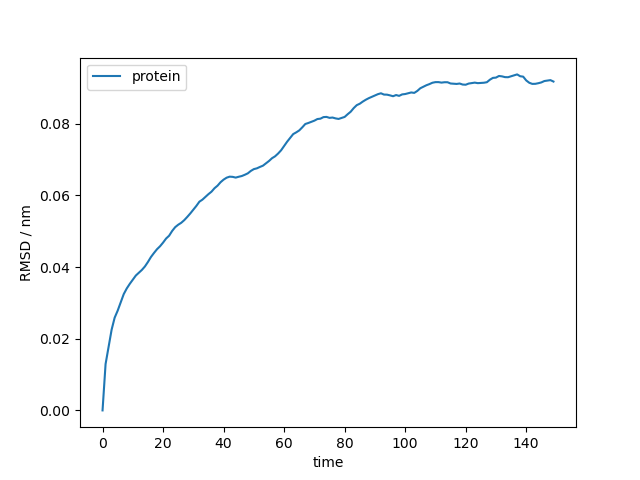

In [7]:
# make sure rmsd plot was generated
from IPython.display import Image
Image(filename=registry.get_mapped_path('fig0_221947'))

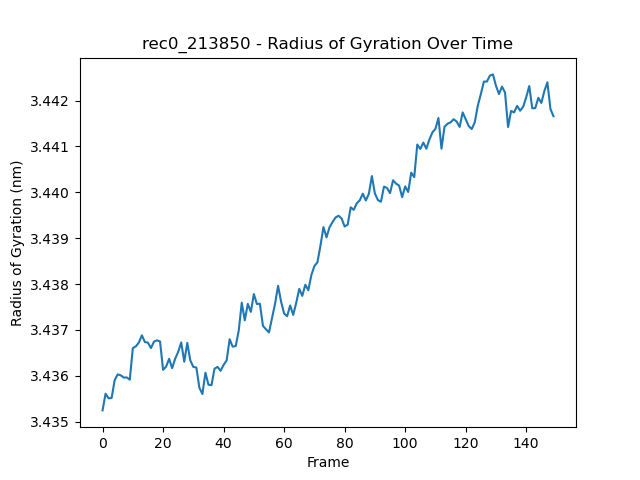

In [11]:
# make sure rgy plot was generated
from IPython.display import Image
Image(filename=registry.get_mapped_path('fig0_221939'))

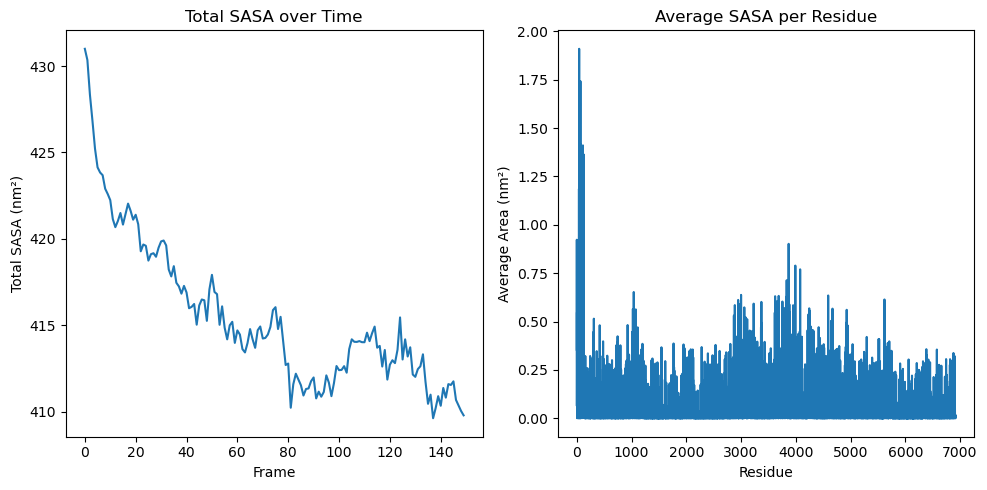

In [10]:
# make sure sasa plot was generated
from IPython.display import Image
Image(filename=registry.get_mapped_path('fig0_221933'))

In [9]:
# make sure trajectory and topology exist (sim2)
traj_path_2 = registry.get_mapped_path("rec0_215231")
top_path_2 = registry.get_mapped_path("top_sim0_215226")

assert os.path.exists(traj_path_2)
assert os.path.exists(top_path_2)

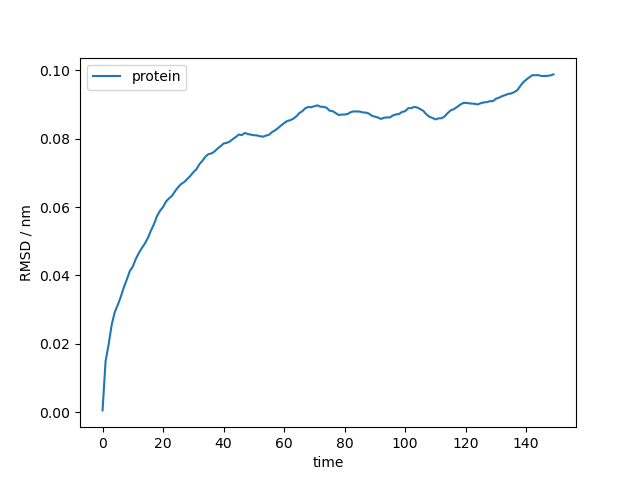

In [8]:
# make sure rmsd plot was generated (sim2)
from IPython.display import Image
Image(filename=registry.get_mapped_path('fig0_221953'))

In [16]:
#verify the total cost
def calculate_llm_cost(input_tokens, output_tokens, model):
    pricing_2024 = {
        "gpt-4-1106-preview": {"input": 10/1e6, "output": 30/1e6},
        "gpt-3.5-turbo-0125": {"input": 0.5/1e6, "output": 1.5/1e6},
        "gpt-4-turbo-2024-04-09": {"input": 10/1e6, "output": 30/1e6},
        "gpt-4o-2024-08-06": {"input": 5/1e6, "output": 15/1e6},
        "llama-v3p1-70b-instruct": {"input": 0.9/1e6, "output": 0.9/1e6},
        "llama-v3p1-405b-instruct": {"input": 3/1e6, "output": 3/1e6},
        "claude-3-opus": {"input": 15/1e6, "output": 75/1e6},
        "claude-3.5-sonnet": {"input": 3/1e6, "output": 15/1e6},
    }
    pricing_2025 = {
        "gpt-4-1106-preview": {"input": 10/1e6, "output": 30/1e6},
        "gpt-3.5-turbo-0125": {"input": 0.5/1e6, "output": 1.5/1e6},
        "gpt-4-turbo-2024-04-09": {"input": 10/1e6, "output": 30/1e6},
        "gpt-4o-2024-08-06": {"input": 2.5/1e6, "output": 10/1e6},
        "llama-v3p1-70b-instruct": {"input": 0.9/1e6, "output": 0.9/1e6},
        "llama-v3p1-405b-instruct": {"input": 3/1e6, "output": 3/1e6},
    }
    
    prices = pricing_2025[model]
    cost = (input_tokens * prices["input"]) + (output_tokens * prices["output"])
    return round(cost, 6)

llm_cost = calculate_llm_cost(cb.prompt_tokens, cb.completion_tokens, agent.llm.model_name)
print('Input tokens:',cb.prompt_tokens)
print('Output tokens:',cb.completion_tokens)
print('LLM costs: $',llm_cost)

Input tokens: 125910
Output tokens: 3608
LLM costs: $ 1.36734
